In [1]:
#代码示例：6-1
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=224

train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_inception/train/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_inception/test/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

Using TensorFlow backend.


Found 952 images belonging to 17 classes.
Found 408 images belonging to 17 classes.


<Figure size 432x288 with 0 Axes>

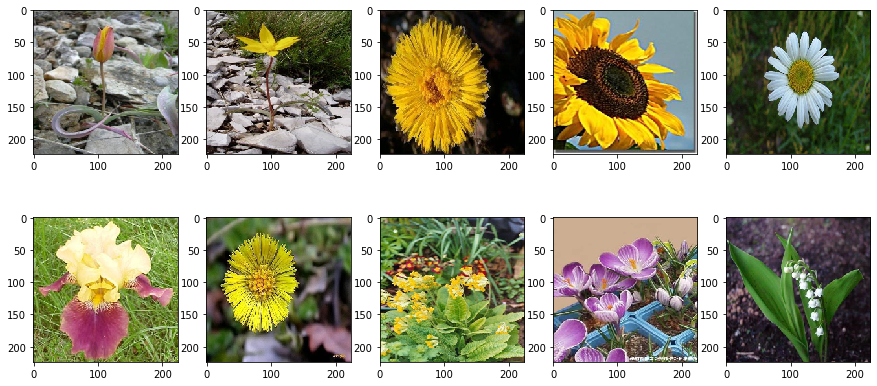

In [2]:
#代码示例：6-2
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(7)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [3]:
#代码示例：6-3
from keras.layers import Conv2D, BatchNormalization, MaxPooling2D
from keras.layers import Flatten, Dropout, Dense, Input, concatenate
from keras import Model

#输入：224*224*3
input_layer = Input([IMSIZE,IMSIZE,3]) 
x = input_layer

#第一层:使用7x7的卷积核（滑动IMSIZE = 224,步长2，same padding），64通道；然后经过3x3的max pooling（步长为2）
x = Conv2D(64,(7,7),strides=(2,2),padding='same',activation='relu')(x) #para=(3*7*7+1)*64=9472
x = BatchNormalization(axis=3)(x) #para=4*64=256
x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x) 

#第二层:使用3x3的卷积核（滑动步长为1，same padding），192通道；然后经过3x3的max pooling（步长为2）
x = Conv2D(192,(3,3),strides=(1,1),padding='same',activation='relu')(x) #para=(64*3*3+1)*192=110784
x = BatchNormalization(axis=3)(x) #para=4*192=768
x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x) 

for i in range(9):
    #第三层:Inception 3a。后面的3b，4a-4e，5a，5b都用3a近似替代
    ##64个1x1的卷积核
    branch1x1 = Conv2D(64,(1,1),strides=(1,1),padding='same',activation='relu')(x) #para=(192*1*1+1)*64=12352
    branch1x1 = BatchNormalization(axis=3)(branch1x1) #para=4*64=256
    ##96个1x1的卷积核，再进行128个3x3的卷积
    branch3x3 = Conv2D(96,(1,1),strides=(1,1),padding='same',activation='relu')(x) #para=(192*1*1+1)*96=18528
    branch3x3 = BatchNormalization(axis=3)(branch3x3) #para=4*96=384
    branch3x3 = Conv2D(128,(3,3),strides=(1,1),padding='same',activation='relu')(branch3x3) #para=(96*3*3+1)*128=110720
    branch3x3 = BatchNormalization(axis=3)(branch3x3) #para=4*128=512
    ##16个1x1的卷积核，再进行32个5x5的卷积
    branch5x5 = Conv2D(16,(1,1),strides=(1,1),padding='same',activation='relu')(x) #para=(192*1*1+1)*16=3088
    branch5x5 = BatchNormalization(axis=3)(branch5x5) #para=4*16=64
    branch5x5 = Conv2D(32,(5,5),strides=(1,1),padding='same',activation='relu')(branch5x5) #para=(16*5*5+1)*32=12832
    branch5x5 = BatchNormalization(axis=3)(branch5x5) #para=4*32=128
    ##pool层，使用3x3的核，输出28x28x192，然后进行32个1x1的卷积
    branchpool = MaxPooling2D(pool_size=(3,3),strides=(1,1),padding='same')(x)
    branchpool = Conv2D(32,(1,1),strides=(1,1),padding='same',activation='relu')(branchpool) #para=(192*1*1+1)*32=6176
    branchpool = BatchNormalization(axis=3)(branchpool) #para=4*32=128
    x = concatenate([branch1x1,branch3x3,branch5x5,branchpool],axis=3)
    x = MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='same')(x)


x = Dropout(0.4)(x)
x = Flatten()(x)
x = Dense(17,activation='softmax')(x)
output_layer=x
model=Model(input_layer,output_layer)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 224, 224, 3)  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 112, 112, 64) 9472        input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 112, 112, 64) 256         conv2d_1[0][0]                   
__________________________________________________________________________________________________
max_pooling2d_1 (MaxPooling2D)  (None, 56, 56, 64)   0           batch_normalization_1[0][0]      
____________________________________________________________________________________________

In [4]:
#代码示例：6-4
from keras.optimizers import Adam
model.compile(loss='categorical_crossentropy', optimizer=Adam(lr=0.001), metrics=['accuracy'])
model.fit_generator(train_generator,epochs=10,validation_data=validation_generator)

Epoch 1/10
10/10 [==============================] - 42s 4s/step - loss: 3.8945 - accuracy: 0.0651 - val_loss: 2.8380 - val_accuracy: 0.0588
Epoch 2/10
10/10 [==============================] - 5s 520ms/step - loss: 3.4822 - accuracy: 0.1019 - val_loss: 2.8312 - val_accuracy: 0.0588
Epoch 3/10
10/10 [==============================] - 8s 827ms/step - loss: 3.0883 - accuracy: 0.1733 - val_loss: 2.7720 - val_accuracy: 0.0588
Epoch 4/10
10/10 [==============================] - 9s 928ms/step - loss: 2.6207 - accuracy: 0.2342 - val_loss: 2.8456 - val_accuracy: 0.0588
Epoch 5/10
10/10 [==============================] - 8s 831ms/step - loss: 2.3797 - accuracy: 0.2805 - val_loss: 2.9047 - val_accuracy: 0.0588
Epoch 6/10
10/10 [==============================] - 9s 926ms/step - loss: 2.0440 - accuracy: 0.3813 - val_loss: 2.8755 - val_accuracy: 0.0613
Epoch 7/10
10/10 [==============================] - 9s 885ms/step - loss: 1.7407 - accuracy: 0.4286 - val_loss: 2.8926 - val_accuracy: 0.0588
Epoch 8/

Using TensorFlow backend.


Found 1612 images belonging to 3 classes.
Found 355 images belonging to 3 classes.


<Figure size 432x288 with 0 Axes>

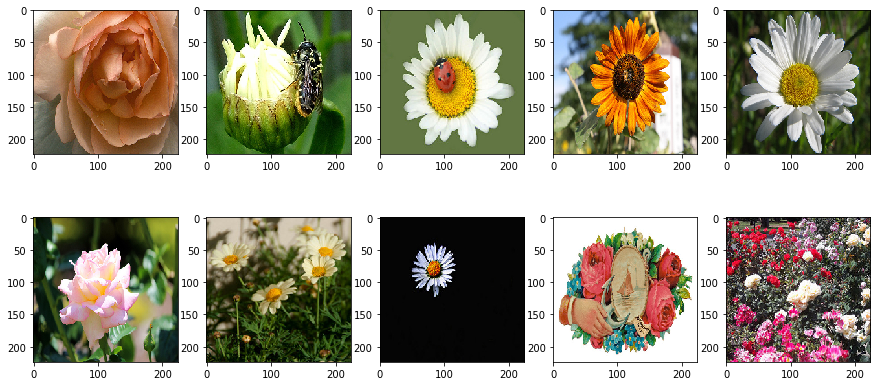

In [1]:
#代码示例：6-5
from matplotlib import pyplot as plt
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=224
train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_res/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_res/validation',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(7)
fig.set_figwidth(15)
ax=ax.flatten()

X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [2]:
#代码示例：6-6
from keras.layers import Input
from keras.layers import Activation, Conv2D, BatchNormalization, add, MaxPooling2D

NB_CLASS=3
IM_WIDTH=224
IM_HEIGHT=224

inpt = Input(shape=(IM_WIDTH, IM_HEIGHT, 3))

x = Conv2D(64, (7,7), padding='same', strides=(2,2), activation='relu')(inpt)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization
x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)
x0 = x

In [3]:
#代码示例：6-7
# 一个block
x = Conv2D(64, (1,1), padding='same', strides=(1,1), activation='relu')(x)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization
x = Conv2D(64, (3,3), padding='same', strides=(1,1), activation='relu')(x)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization
x = Conv2D(256, (1,1), padding='same', strides=(1,1), activation=None)(x)
x = BatchNormalization()(x)
# 一个卷积层加一个batch normalization

# 下面两步为了把输入64通道的数据转换为256个通道，用来让x0和x维数相同，可以进行加法计算，文章中虚线得的部分
x0 = Conv2D(256,(1,1),padding='same',strides=(1,1),activation='relu')(x0)
x0 = BatchNormalization()(x0)
x = add([x,x0])# add把输入的x和经过一个block之后输出的结果加在一起
x = Activation('relu')(x)#求和之后的结果再做一次relu
x0 = x # 把输入存到一个另外的变量中

In [4]:
#代码示例：6-8
from keras.models import Model
model = Model(inputs=inpt,outputs=x)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 224, 224, 3)  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 112, 112, 64) 9472        input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 112, 112, 64) 256         conv2d_1[0][0]                   
__________________________________________________________________________________________________
max_pooling2d_1 (MaxPooling2D)  (None, 56, 56, 64)   0           batch_normalization_1[0][0]      
____________________________________________________________________________________________

In [5]:
#代码示例：6-9
#在resnet最后的部分添加一个dense层，并输出一个二维的结果用来分类
from keras.layers import Dense, Flatten
x = model.output
x = Flatten()(x)
predictions = Dense(NB_CLASS,activation='softmax')(x)
model_res = Model(inputs=model.input,outputs=predictions)

In [6]:
#代码示例：6-10
from keras.optimizers import Adam
model_res.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])

model_res.fit_generator(
    train_generator,
    steps_per_epoch=100,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=100)

Epoch 1/5
100/100 [==============================] - 91s 906ms/step - loss: 11.1434 - accuracy: 0.8270 - val_loss: 7.4657 - val_accuracy: 0.3634
Epoch 2/5
100/100 [==============================] - 87s 875ms/step - loss: 1.5124 - accuracy: 0.9473 - val_loss: 7.5786 - val_accuracy: 0.5324
Epoch 3/5
100/100 [==============================] - 86s 856ms/step - loss: 1.4989 - accuracy: 0.9587 - val_loss: 9.3369 - val_accuracy: 0.5465
Epoch 4/5
100/100 [==============================] - 85s 849ms/step - loss: 0.2470 - accuracy: 0.9879 - val_loss: 10.0932 - val_accuracy: 0.7127
Epoch 5/5
100/100 [==============================] - 85s 848ms/step - loss: 0.0460 - accuracy: 0.9978 - val_loss: 16.5914 - val_accuracy: 0.7352


In [1]:
#代码示例：6-11
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=128

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/data_des/test',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')
train_generator = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.5,
    rotation_range=30,
    zoom_range=0.2, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True).flow_from_directory(
    '/course7/data/data_des/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

Using TensorFlow backend.


Found 10383 images belonging to 2 classes.
Found 15304 images belonging to 2 classes.


<Figure size 432x288 with 0 Axes>

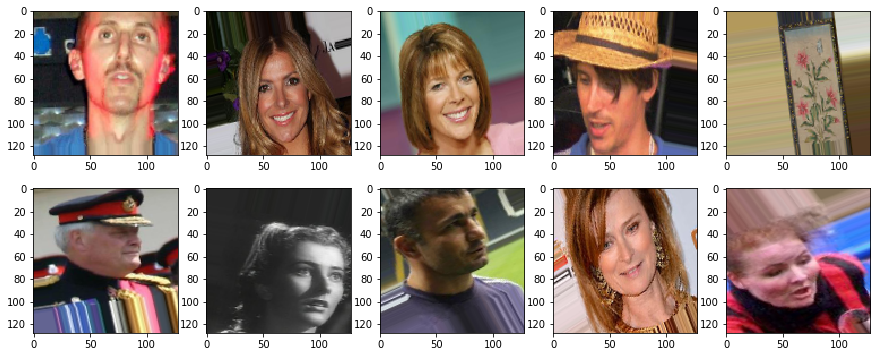

In [2]:
#代码示例：6-12
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [3]:
#代码示例：6-13
from keras.layers import Input,BatchNormalization,Conv2D,Dense,Flatten,Input,MaxPooling2D,Concatenate
from keras.layers.pooling import AveragePooling2D,GlobalAveragePooling2D
from keras import Model

IMSIZE=128

# 每个dense block中dense layer数目 
nb_layers = 3
# 增长率
growth_rate = 32  

# 输入层
input_layer = Input([IMSIZE,IMSIZE,3])
x = input_layer

# 初始卷积层
x = BatchNormalization()(x)
x = Conv2D(growth_rate*2, (3,3), padding='same', activation='relu')(x)

In [4]:
#代码示例：6-14
# 设置 [Dense Block + Transition Block] 多个，此处以1个为例
for j in range(3):
    # 1.Dense Block
    # 用一个列表存放提供特征的层
    feature_list = [x]
    for i in range(nb_layers):   
        x = BatchNormalization()(x)
        x = Conv2D(growth_rate, (3, 3), padding="same", activation='relu')(x)   
        feature_list.append(x)
        if i<(nb_layers-1):
            x = Concatenate()(feature_list)
        
    
    # 2.Transition Block
    x = BatchNormalization()(x)
    x = Conv2D(growth_rate, (1, 1), padding="same", activation='relu')(x)
    x = AveragePooling2D((2, 2), strides=(2, 2))(x)

In [5]:
#代码示例：6-15
# 设置最后一个Dense Block （最后一个Dense Block不需要Transition Block）
feature_list = [x]
for i in range(nb_layers):            
    x = Conv2D(growth_rate, (3, 3), padding="same", activation='relu')(x)   
    feature_list.append(x)
    if i<(nb_layers-1):
        x = Concatenate()(feature_list)

# 全局池化
x = GlobalAveragePooling2D()(x)
x = Dense(2,activation='softmax')(x)
output_layer = x
model = Model(input_layer,output_layer)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 128, 128, 3)  0                                            
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 128, 128, 3)  12          input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 64) 1792        batch_normalization_1[0][0]      
__________________________________________________________________________________________________
batch_normalization_2 (BatchNor (None, 128, 128, 64) 256         conv2d_1[0][0]                   
____________________________________________________________________________________________

In [6]:
#代码示例：6-16
from keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
model.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
154/154 [==============================] - 249s 2s/step - loss: 0.5264 - accuracy: 0.7719 - val_loss: 0.4584 - val_accuracy: 0.7642
Epoch 2/5
154/154 [==============================] - 241s 2s/step - loss: 0.5151 - accuracy: 0.7731 - val_loss: 0.5879 - val_accuracy: 0.7642
Epoch 3/5
154/154 [==============================] - 225s 1s/step - loss: 0.4924 - accuracy: 0.7845 - val_loss: 0.5458 - val_accuracy: 0.7098
Epoch 4/5
154/154 [==============================] - 237s 2s/step - loss: 0.4736 - accuracy: 0.7944 - val_loss: 0.4065 - val_accuracy: 0.8007
Epoch 5/5
154/154 [==============================] - 238s 2s/step - loss: 0.4588 - accuracy: 0.8053 - val_loss: 0.3100 - val_accuracy: 0.8121


In [3]:
# 载入必要的库
import numpy as np
import tensorflow as tf
import keras

from matplotlib import pyplot as plt

from keras import Model
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D,AveragePooling2D
from keras.layers import Flatten, Dropout, Dense, Input, Concatenate, add, Activation,ZeroPadding2D
from keras.layers import ReLU, DepthwiseConv2D

Found 762 images belonging to 10 classes.
Found 1157 images belonging to 10 classes.


<Figure size 432x288 with 0 Axes>

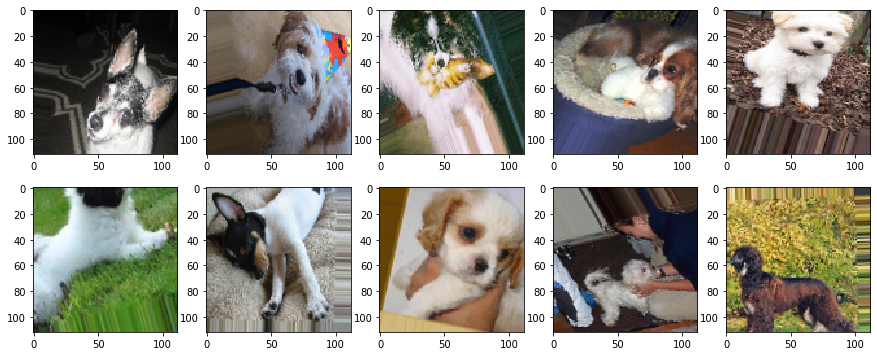

In [4]:
#代码示例：6-17
from keras.preprocessing.image import ImageDataGenerator
import random
random.seed(2019425)

# Set image size
IMSIZE=112

# laod validation data
datagen = ImageDataGenerator(rescale=1. / 255,
                             shear_range=0.5,
                             rotation_range=30,
                             zoom_range=0.2,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             horizontal_flip=True,
                             validation_split = 0.4)

validation_generator = datagen.flow_from_directory(
    '/course7/data/data_mob/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical',
    subset = 'validation')

train_generator = datagen.flow_from_directory(
    '/course7/data/data_mob/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=150,
    class_mode='categorical',
    subset = 'training')

plt.figure()
fig, ax = plt.subplots(2, 5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax = ax.flatten()
X, Y = next(validation_generator)
for i in range(10):
    ax[i].imshow(X[i, :, :, ])
plt.show()

In [5]:
#代码示例：6-18
def _depthwise_conv_block(inputs, pointwise_conv_filters, alpha,
                           strides=(1, 1), block_id=1):

    """Adds a depthwise convolution block.

    A depthwise convolution block consists of a depthwise conv,
    batch normalization, relu6, pointwise convolution,
    batch normalization and relu6 activation.

    # Arguments

        inputs: Input tensor of shape `(rows, cols, channels)`

        pointwise_conv_filters: Integer, the dimensionality of the output space
            (i.e. the number of output filters in the pointwise convolution).

        alpha: controls the width of the network.

        strides: An integer or tuple/list of 2 integers,
            specifying the strides of the convolution
            along the width and height.

        block_id: Integer, a unique identification designating
            the block number.
            
    # Returns
        Output tensor of block.

    """

    pointwise_conv_filters = int(pointwise_conv_filters * alpha)

    if strides == (1, 1):
        x = inputs
    else:
        x = ZeroPadding2D(((0, 1), (0, 1)),
                          name='conv_pad_%d' % block_id)(inputs)

    x = DepthwiseConv2D((3, 3),
                               padding='same' if strides == (1, 1) else 'valid',
                               strides=strides,
                               use_bias=False,
                               name='conv_dw_%d' % block_id)(x)
    x = BatchNormalization(axis=-1, 
                                  name='conv_dw_%d_bn' % block_id)(x)
    x = ReLU(6., name='conv_dw_%d_relu' % block_id)(x)
    x = Conv2D(pointwise_conv_filters, (1, 1),
                      padding='same',
                      use_bias=False,
                      strides=(1, 1),
                      name='conv_pw_%d' % block_id)(x)
    x = BatchNormalization(axis=-1,
                                  name='conv_pw_%d_bn' % block_id)(x)
    
    return ReLU(6., name='conv_pw_%d_relu' % block_id)(x)

In [6]:
#代码示例：6-19
from keras.layers import ZeroPadding2D, ReLU, DepthwiseConv2D
alpha = 1
depth_multiplier = 1

# 输入层
input_layer = Input([IMSIZE,IMSIZE,3]) 

# 初始卷积层
x = input_layer
x = ZeroPadding2D(padding = ((0,1),(0,1)),name='conv1_pad')(x)
x = Conv2D(32,(3,3),padding='valid',use_bias=False,strides=(2,2),name='conv1')(x)
x = BatchNormalization(axis=-1, name='conv1_bn')(x)
x = ReLU(6,name='conv1_relu')(x)

# 保留其中的一些深度可分离卷积层
x = _depthwise_conv_block(x, 64, alpha, block_id=1)
x = _depthwise_conv_block(x, 128, alpha, strides=(2, 2), block_id=2)
x = _depthwise_conv_block(x, 256, alpha, strides=(2, 2), block_id=3)
x = _depthwise_conv_block(x, 512, alpha, strides=(2, 2), block_id=4)
x = _depthwise_conv_block(x, 1024, alpha, strides=(2, 2), block_id=5)


# Average Pooling
x = GlobalAveragePooling2D()(x)

x = Dense(10,activation='softmax')(x)
model = Model(inputs=input_layer,outputs=x)
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 112, 112, 3)       0         
_________________________________________________________________
conv1_pad (ZeroPadding2D)    (None, 113, 113, 3)       0         
_________________________________________________________________
conv1 (Conv2D)               (None, 56, 56, 32)        864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 56, 56, 32)        128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 56, 56, 32)        0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 56, 56, 32)        288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 56, 56, 32)        128 

In [7]:
#代码示例：6-20
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(lr=0.001),
              metrics=['accuracy'])

model.fit_generator(
    train_generator,
    steps_per_epoch=100,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=100)

Epoch 1/5
100/100 [==============================] - 151s 2s/step - loss: 1.9644 - accuracy: 0.3025 - val_loss: 2.3323 - val_accuracy: 0.1123
Epoch 2/5
100/100 [==============================] - 144s 1s/step - loss: 1.4985 - accuracy: 0.4772 - val_loss: 3.0716 - val_accuracy: 0.1108
Epoch 3/5
100/100 [==============================] - 143s 1s/step - loss: 1.0921 - accuracy: 0.6253 - val_loss: 4.0899 - val_accuracy: 0.1111
Epoch 4/5
100/100 [==============================] - 147s 1s/step - loss: 0.7590 - accuracy: 0.7449 - val_loss: 4.8704 - val_accuracy: 0.1327
Epoch 5/5
100/100 [==============================] - 144s 1s/step - loss: 0.5174 - accuracy: 0.8270 - val_loss: 5.9450 - val_accuracy: 0.1438


In [1]:
#代码示例：6-21
from keras.applications.inception_v3 import preprocess_input
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=224

validation_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input).flow_from_directory(
    '/course7/data/CatDog/validation',
    target_size=(IMSIZE, IMSIZE),
    batch_size=100,
    class_mode='categorical')

Using TensorFlow backend.


Found 10000 images belonging to 2 classes.


In [2]:
#代码示例：6-22
train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.5,
    rotation_range=30,
    zoom_range=0.2, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True).flow_from_directory(
    '/course7/data/CatDog/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=150,
    class_mode='categorical')

Found 15000 images belonging to 2 classes.


<Figure size 432x288 with 0 Axes>

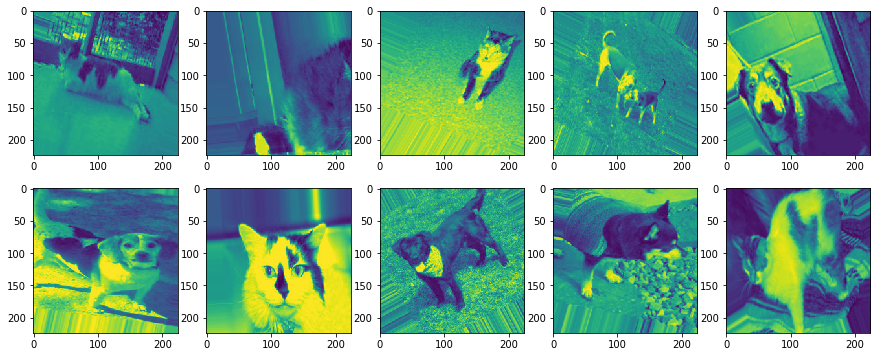

In [3]:
#代码示例：6-23
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,0])

In [4]:
#代码示例：6-24
from keras.applications.inception_v3 import InceptionV3
from keras.layers import GlobalAveragePooling2D, Dense, Activation
from keras import Model

base_model = InceptionV3(weights='imagenet', include_top=False)
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(2,activation='softmax')(x)
model=Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers:
    layer.trainable = False
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, None, None, 3 0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, None, None, 3 864         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, None, None, 3 96          conv2d_1[0][0]                   
__________________________________________________________________________________________________
activation_1 (Activation)       (None, None, None, 3 0           batch_normalization_1[0][0]      
____________________________________________________________________________________________

In [5]:
#代码示例：6-25
from keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
model.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
100/100 [==============================] - 414s 4s/step - loss: 0.3254 - accuracy: 0.8634 - val_loss: 0.0510 - val_accuracy: 0.9726
Epoch 2/5
100/100 [==============================] - 402s 4s/step - loss: 0.2052 - accuracy: 0.9127 - val_loss: 0.1471 - val_accuracy: 0.9695
Epoch 3/5
100/100 [==============================] - 374s 4s/step - loss: 0.1769 - accuracy: 0.9259 - val_loss: 0.0539 - val_accuracy: 0.9841
Epoch 4/5
100/100 [==============================] - 383s 4s/step - loss: 0.1647 - accuracy: 0.9311 - val_loss: 0.0018 - val_accuracy: 0.9852
Epoch 5/5
100/100 [==============================] - 371s 4s/step - loss: 0.1625 - accuracy: 0.9315 - val_loss: 0.1181 - val_accuracy: 0.9846
